<a href="https://colab.research.google.com/github/muhyassin09/yasinnn/blob/main/medical-survival-analysis/scripts/02_kaplan-meier-%26-log-rank-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HEART FAILURE CLINICAL RECORDS — KAPLAN-MEIER SURVIVAL ANALYSIS

Environment Setup

In [1]:
!pip install -q lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 7.0 MB/s eta 0:00:00


In [2]:
import os
import zipfile
import urllib.request
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.plotting import add_at_risk_counts

INPUT DATA

In [3]:
heart_failure_data = pd.read_csv('heart_failure_clinical_records_dataset.csv')

In [4]:
heart_failure_data.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [6]:
heart_failure_data = heart_failure_data.apply(pd.to_numeric)

In [7]:
n_deaths = heart_failure_data["DEATH_EVENT"].sum()
n_total = len(heart_failure_data)

print(f"Loaded cohort: N = {n_total} rows | Deaths = {n_deaths} ({100 * n_deaths / n_total:.1f}%)")

Loaded cohort: N = 299 rows | Deaths = 96 (32.1%)


In [8]:
heart_failure_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


### KAPLAN-MEIER ESTIMATION, STRATIFIED BY HYPERTENSION

In [11]:
hypertension_group = heart_failure_data[heart_failure_data ["high_blood_pressure"] == 1]
no_hypertension_group = heart_failure_data[heart_failure_data["high_blood_pressure"] == 0]

In [12]:
kmf_hypertension = KaplanMeierFitter(label="Hypertension: Yes")
kmf_no_hypertension = KaplanMeierFitter(label="Hypertension: No")

In [13]:
kmf_hypertension.fit(
    durations=hypertension_group["time"],
    event_observed=hypertension_group["DEATH_EVENT"]
)

kmf_no_hypertension.fit(
    durations=no_hypertension_group["time"],
    event_observed=no_hypertension_group["DEATH_EVENT"]
)

<lifelines.KaplanMeierFitter:"Hypertension: No", fitted with 194 total observations, 137 right-censored observations>

### LOG-RANK TEST
The log-rank test compares the two survival curves across their ENTIRE follow-up period (not just at one timepoint), testing the null hypothesis that hypertensive and non-hypertensive patients have identical underlying survival functions. A small p-value (conventionally < 0.05) indicates the two curves are unlikely to come from the same survival distribution — i.e. hypertension status is statistically associated with differential survival time in this cohort.


In [14]:
logrank_result = logrank_test(
    durations_A=hypertension_group["time"],
    durations_B=no_hypertension_group["time"],
    event_observed_A=hypertension_group["DEATH_EVENT"],
    event_observed_B=no_hypertension_group["DEATH_EVENT"]
)

In [15]:
logrank_p_value = logrank_result.p_value
print(f"Log-rank test p-value (Hypertension vs. No Hypertension): {logrank_p_value:.4f}")

if logrank_p_value < 0.05:
    print("Interpretation: survival distributions differ significantly between groups.")
else:
    print("Interpretation: no statistically significant difference in survival distributions detected.")

Log-rank test p-value (Hypertension vs. No Hypertension): 0.0358
Interpretation: survival distributions differ significantly between groups.


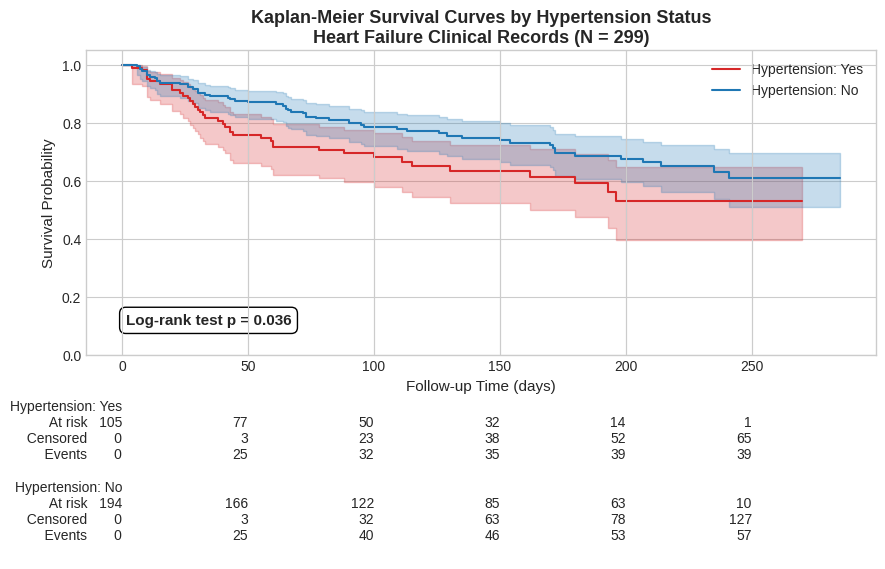

In [21]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(9, 6))
kmf_hypertension.plot_survival_function(ax=ax, ci_show=True, color="#D62728")
kmf_no_hypertension.plot_survival_function(ax=ax, ci_show=True, color="#1F77B4")

ax.text(
    0.05, 0.10,
    f"Log-rank test p = {logrank_p_value:.3f}",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold",
    bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.4")
)

ax.set_title(
    "Kaplan-Meier Survival Curves by Hypertension Status\nHeart Failure Clinical Records (N = 299)",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Follow-up Time (days)", fontsize=11)
ax.set_ylabel("Survival Probability", fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(title="", loc="upper right", fontsize=10)

add_at_risk_counts(kmf_hypertension, kmf_no_hypertension, ax=ax)

plt.tight_layout()
plt.savefig("km_curve_hypertension.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
median_survival_hypertension = kmf_hypertension.median_survival_time_
median_survival_no_hypertension = kmf_no_hypertension.median_survival_time_

print("\n--- Median Survival Time Summary ---")
print(f"Hypertension: Yes -> "
      f"{'Not reached' if pd.isna(median_survival_hypertension) else f'{median_survival_hypertension:.0f} days'}")
print(f"Hypertension: No  -> "
      f"{'Not reached' if pd.isna(median_survival_no_hypertension) else f'{median_survival_no_hypertension:.0f} days'}")


--- Median Survival Time Summary ---
Hypertension: Yes -> inf days
Hypertension: No  -> inf days


In [23]:
import numpy as np

print("\n--- Median Survival Time Summary ---")
print(f"Hypertension: Yes -> "
      f"{'Not reached' if np.isinf(median_survival_hypertension) else f'{median_survival_hypertension:.0f} days'}")
print(f"Hypertension: No  -> "
      f"{'Not reached' if np.isinf(median_survival_no_hypertension) else f'{median_survival_no_hypertension:.0f} days'}")


--- Median Survival Time Summary ---
Hypertension: Yes -> Not reached
Hypertension: No  -> Not reached
